PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores

 ¡Hola y bienvenido a la Práctica de Machine Learning más difícil del mundo!

Este notebook está diseñado para ayudarte a comenzar con la práctica.

En este cuaderno vamos a:

- Descargar y explorar el conjunto de datos
- Entrenar y evaluar este primer modelo de aprendizaje automático
- Implementar el modelo para comenzar a realizar predicciones

In [2]:
# Instala dependencias
!pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1
!pip install -q --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline

1.- DATASET

A alto nivel, trabajaremos con un conjunto de datos tabulares que describe el mercado de valores a lo largo del tiempo.

Cada fila representa una acción en un momento específico, donde "id" es la identificación de la acción y "era" es la fecha. 

Las características describen los atributos de la acción (por ejemplo, el ratio Price/Earning) conocidos en una fecha dada, y "target" es una medida de rendimientos a 20 días.

El conjunto de datos está ofuscado, lo que significa que los identificadores de acciones (stocks) subyacentes, los nombres de las características y las definiciones de objetivos son anónimos. Esto hace que podamos trabajar con estos datos de forma gratuita y que puedan modelarse sin ningún conocimiento (¡o sesgo!) del dominio financiero.

Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.

In [1]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [2]:
import pandas as pd
import json

# Descarga los datos de entrenamiento y los metadatos de las características
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");

# Carga solo el conjunto de features "medium" para reducir el uso de memoria y acelerar el entrenamiento del modelo 
# O bien, utiliza el conjunto de features "all" para usar todas las características
# En este ejemplo descargaremos solo el "small"
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["small"]
#feature_cols = feature_metadata["feature_sets"]["small"]
#train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"] + feature_cols + ["target"])
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
# Comenta la línea a continuación para utilizar todos los datos.
train = train[train["era"].isin(train["era"].unique()[::4])]
train

2025-10-28 16:19:04,154 INFO numerapi.utils: starting download
v5.0/train.parquet: 2.37GB [06:30, 6.06MB/s]                             
2025-10-28 16:25:37,635 INFO numerapi.utils: starting download
v5.0/features.json: 291kB [00:01, 279kB/s]                             


small 42
medium 705
all 2376


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,1,2,1,0,3,2,1,1,...,2,2,1,2,3,3,3,2,2,1
nffc9844c1c7a6a9,0573,0.25,2,1,2,1,4,2,2,4,...,4,0,0,3,1,3,3,2,3,2
nffd79773f4109bb,0573,0.50,3,4,0,3,4,1,0,1,...,3,0,0,0,1,1,4,0,1,2


ERAS:

Como se mencionó anteriormente, cada "era" corresponde a una fecha diferente. Cada "era" tiene exactamente una semana de diferencia.

Es útil pensar en filas de acciones dentro de la misma "era" como un solo ejemplo. A lo largo de este notebook hablaremos de cosas "por era". Por ejemplo, el número de filas por "era" representa el conjunto de acciones (stocks) dentro de las posibilidades de inversión de algún fondo en esa fecha.

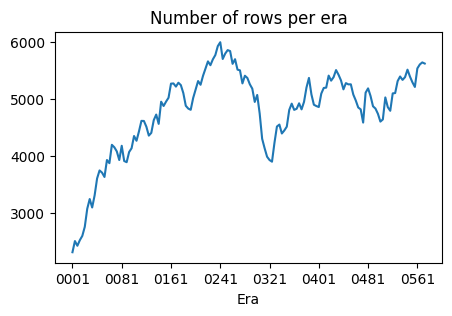

In [7]:
# Muestra el número de filas por era
train.groupby("era").size().plot(title="Number of rows per era", figsize=(5, 3), xlabel="Era");

FEATURES:

Como se mencionó anteriormente, las características son atributos cuantitativos de cada acción: fundamentos como la relación P/E (precio/beneficio), señales técnicas como el RSI, datos de mercado como el interés a corto, datos secundarios como las calificaciones de los analistas y mucho más.

La definición subyacente de cada característica no es importante, solo debes saber que se han incluido estas características en el conjunto de datos porque se cree que pueden ser relevantes para predecir el "target".

In [8]:
# Número de características
len(feature_set)

42

Los valores de las características se agrupan en 5 contenedores iguales: 0, 1, 2, 3, 4. Esta fuerte estandarización de los valores de las características tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

Si faltan datos de una característica particular para esa era (más común en las primeras eras), todos los valores se establecen en 2.


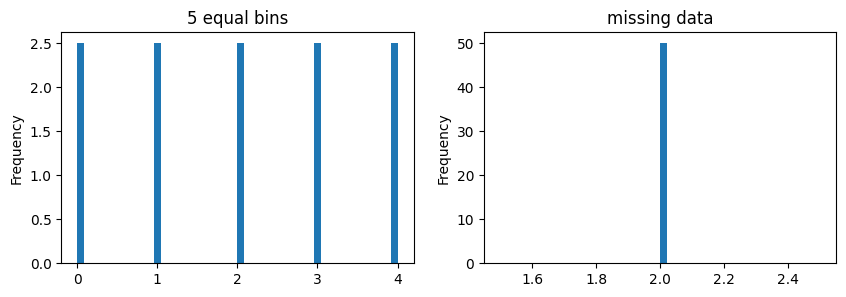

In [9]:
# Compara la distribución de una característica particular (feature_cols[-1]) entre dos períodos diferentes (first_era y last_era) en el conjunto de datos train.
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]
last_era[feature_set[-1]].plot(kind="hist", title="5 equal bins", density=True, bins=50, ax=ax1);
first_era[feature_set[-1]].plot(kind="hist", title="missing data", density=True, bins=50, ax=ax2);

TARGET:

El "target" es una medida de los rendimientos del mercado de valores a 20 días. Específicamente, es una medida de rendimientos "específicos de acciones" que no se "explican" por tendencias más amplias en el mercado, país, sector o "factores" bien conocidos.

Los valores del "target" se agrupan en 5 contenedores desiguales: 0, 0,25, 0,5, 0,75, 1,0. Nuevamente, esta fuerte estandarización de los valores de target tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

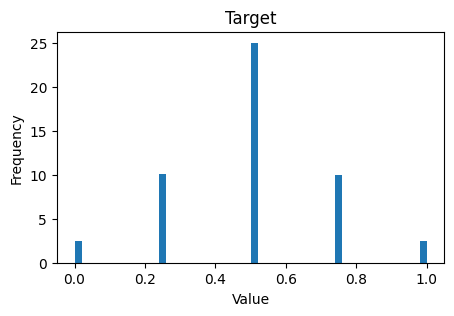

In [10]:
# Histograma (densidad) de "target"
train["target"].plot(kind="hist", title="Target", figsize=(5, 3), xlabel="Value", density=True, bins=50);

2.- MODELING

Entrenamiento del modelo:

Eres libre de utilizar cualquier algoritmo visto en clase. Pero, en este ejemplo, usaremos LGBMRegressor, basado en árboles de decisión para predecir variables continuas. Es una opción popular para las predicciones de este tipo.

In [11]:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html 
import lightgbm as lgb #En mi mac, tuve que instalar libomp: "brew install libomp"

# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1
)

# This will take a few minutes 🍵
model.fit(
  train[feature_set],
  train["target"]
);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 42
[LightGBM] [Info] Start training from score 0.500008


Ahora hagamos algunas predicciones con los datos de validación para evaluar el rendimiento de nuestro modelo.

In [12]:
# Descarga validation data 
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/validation.parquet");

# Carga el validation data, filtrando por data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reduce la muestra a cada cuarta era para reducir el uso de memoria y acelerar la evaluación
# Comenta la siguiente línea para usar todos los datos (mayor uso de memoria, inferencia más lenta, evaluación más precisa)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Genera predicciones respecto a las características de validación fuera de la muestra.
# Esto tomará unos pocos minutos 🍵
validation["prediction"] = model.predict(validation[feature_set])
validation[["era", "prediction", "target"]]

2025-10-28 18:21:25,102 INFO numerapi.utils: starting download
v5.0/validation.parquet: 3.55GB [08:50, 6.69MB/s]                              


,era,prediction,target
id,,,
n000c290e4364875,0579,0.494547,0.50
n002a15bc5575bbb,0579,0.517560,0.25
n00309caaa0f955e,0579,0.515683,0.75
n0039cbdcf835708,0579,0.509313,0.50
n004143458984f89,0579,0.483896,0.50
...,...,...,...
nffc45fef92f9990,1183,0.500537,0.50
nffcd993886ef112,1183,0.487059,0.25
nffd2f8483ddb3cc,1183,0.512208,0.25


Evaluación del rendimiento:

La métrica de puntuación principal que usaremos se llama CORR (practica_corr), que es una variante específica de para este caso de uso del coeficiente de correlación de Pearson.

Esta métrica está diseñada para "alinear los incentivos" entre el modelo y el desempeño de un fondo de inversión. Es decir, un modelo con una buena puntuación CORR debería ayudar a un inversor a obtener buenos rendimientos.

In [13]:
from scipy import stats
import numpy as np

# La principal métrica de scoring:
def practica_corr(preds, target):
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

Como se mencionó anteriormente, es importante calificar cada era histórica de forma independiente. Entonces, al evaluar el desempeño de nuestro modelo, deberíamos observar la corrección "por era".

Una cosa que puedes ver aquí es cómo de bajas son las puntuaciones (en el rango de +/- 5% de correlación). Esto es muy normal en el ámbito de las finanzas cuantitativas y es parte de la razón por la que se indica que es la "práctica de aprendizaje automático más difícil" del mundo.


C:\Users\javij\AppData\Local\Temp\ipykernel_21708\38165613.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))


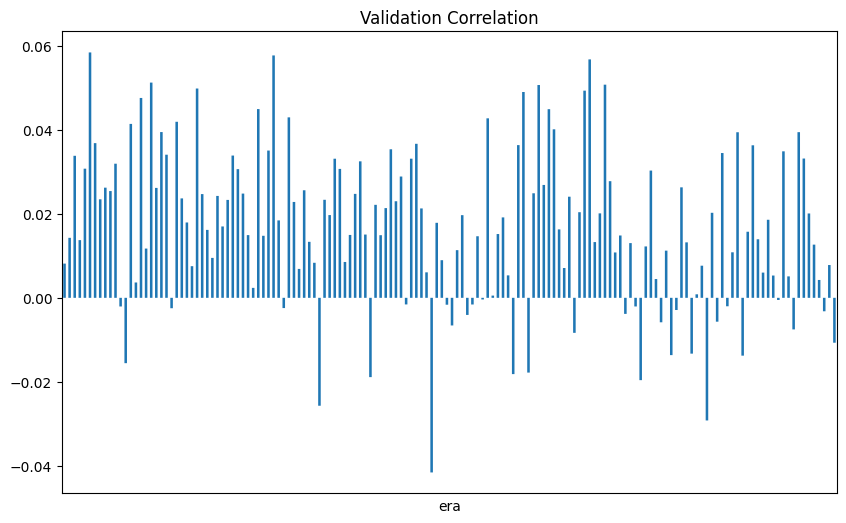

In [14]:
# Calcula la correlación por era entre nuestras predicciones y los valores "target".
per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))

# Gráfica de correlación por "era" 
per_era_corr.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

En lugar de observar la puntuación "corr" de cada "era", resulta útil observar la puntuación "corr" acumulativa.

Esto se denomina "backtesting" en finanzas cuantitativas, donde las personas simulan el desempeño histórico de sus estrategias de inversión, puede considerar este gráfico como una prueba retrospectiva del desempeño de tu modelo durante el período de validación histórica.

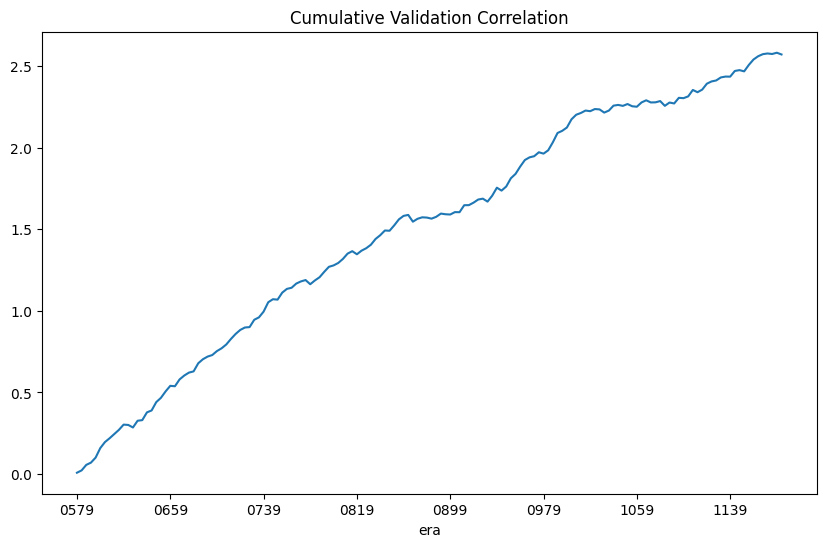

In [15]:
# Gráfica de la correlación acumulada por "era"
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

Métricas de rendimiento:
    
Para evaluar el rendimiento de nuestro modelo, también es útil calcular algunas métricas resumidas durante todo el período de validación.

La media de correlaciones es la medida principal del rendimiento de su modelo.

Sharpe es una medida de la coherencia de tu modelo, un concepto tomado de las finanzas, donde generalmente se refiere a los rendimientos ajustados al riesgo de una estrategia de inversión. Aquí calcularemos Sharpe como la correlación promedio dividida por la desviación estándar de las correlaciones.

La reducción máxima (max_drawdown) es una medida del riesgo de tu modelo, otro concepto tomado de las finanzas, donde generalmente se refiere a la pérdida financiera máxima sufrida por una estrategia de inversión. Aquí calcularemos la reducción máxima como la caída máxima desde el pico hasta el mínimo en la correlación de validación acumulativa.

In [16]:
# Calcula métricas de rendimiento
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

pd.DataFrame({
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}, index=["Value"]).T

,Value
mean,0.016923
std,0.018835
sharpe,0.898501
max_drawdown,0.041581


Estas métricas de rendimiento anteriores no son sorprendentes, pero son lo suficientemente buenas como para comenzar!

SUBMISSIONS

Vamos a evaluar los modelos según su rendimiento en vivo!

La tarea es generar predicciones sobre valores objetivo desconocidos, que representan los rendimientos del mercado de valores dentro de X días.

In [17]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Genera predicciones en vivo
live_predictions = model.predict(live_features[feature_set])

#Evaluar
live_predictions

# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2025-10-28 18:30:37,567 INFO numerapi.utils: starting download
v5.0/live.parquet: 8.39MB [00:02, 2.91MB/s]                            


,prediction
id,
n0001d7c86e30d97,0.495082
n000e08f6b34cb23,0.502329
n000fe8542335e43,0.502463
n001109d843c2d13,0.501111
n00192fee93b82f0,0.486057
...,...
nffdf9c84a1eab41,0.497282
nffe9f00841872a9,0.507405
nffec9fa92e82df9,0.508562


3.- MEJORAS DEL MODELO: FEATURE NEUTRALIZATION


**¿Qué es Feature Neutralization?**

La "neutralización de características" (feature neutralization) es una técnica avanzada utilizada en finanzas cuantitativas para **reducir la exposición del modelo a características específicas** que podrían introducir riesgo no deseado.

**¿Cómo funciona?**

El proceso consiste en:
1. **Ortogonalizar** las predicciones respecto a ciertas características mediante regresión lineal
2. **Eliminar la componente** de las predicciones que puede explicarse linealmente por esas características
3. Mantener solo el **componente "alpha" o señal residual** que no está correlacionado con las características neutralizadas

**¿Por qué es importante?**

- **Reduce el "feature risk"**: Si una característica particular tiene un mal desempeño en el futuro, tus predicciones neutralizadas estarán menos expuestas
- **Mejora la estabilidad**: Las predicciones neutralizadas tienden a ser más consistentes a lo largo del tiempo
- **Alignment con Numerai**: En Numerai, las predicciones neutralizadas suelen tener mejor performance ajustado por riesgo

**Implementación:**

La neutralización se realiza mediante una regresión lineal:
- `predicciones_neutralizadas = predicciones - β * características`
- Donde β se obtiene minimizando la correlación entre predicciones y características


In [18]:
from sklearn.linear_model import LinearRegression

def neutralize_predictions(predictions, features, proportion=1.0):
    """
    Neutraliza las predicciones respecto a las características dadas.
    
    Args:
        predictions: Series o array con las predicciones del modelo
        features: DataFrame con las características a neutralizar
        proportion: Proporción de neutralización (0.0 = sin neutralización, 1.0 = neutralización completa)
    
    Returns:
        Series con las predicciones neutralizadas
    """
    # Convertir predicciones a numpy array si es necesario
    if isinstance(predictions, pd.Series):
        preds_array = predictions.values.reshape(-1, 1)
        index = predictions.index
    else:
        preds_array = predictions.reshape(-1, 1)
        index = None
    
    # Ajustar regresión lineal: predicciones ~ características
    lr = LinearRegression(fit_intercept=True)
    lr.fit(features, preds_array)
    
    # Calcular predicciones ajustadas (lo que las características "explican")
    predictions_explained = lr.predict(features)
    
    # Neutralizar: eliminar la componente explicada por las características
    # proportion controla qué tanto neutralizamos (1.0 = completo, 0.5 = mitad)
    neutralized = preds_array - (proportion * predictions_explained)
    
    # Devolver como Series si teníamos Series de entrada
    if index is not None:
        return pd.Series(neutralized.flatten(), index=index)
    return neutralized.flatten()


# Aplicar feature neutralization a las predicciones de validación
print("Predicciones originales - estadísticas:")
print(validation["prediction"].describe())
print("\n" + "="*60 + "\n")

# Neutralizar las predicciones respecto a TODAS las características
# Esto reduce significativamente el feature risk
validation["prediction_neutralized"] = neutralize_predictions(
    validation["prediction"], 
    validation[feature_set],
    proportion=0.5  # Neutralización al 50% para balancear performance y estabilidad
)

print("Predicciones neutralizadas - estadísticas:")
print(validation["prediction_neutralized"].describe())
print("\n" + "="*60 + "\n")

# Calcular correlación por era con predicciones neutralizadas
per_era_corr_neutralized = validation.groupby("era").apply(
    lambda x: practica_corr(x["prediction_neutralized"], x["target"])
)

# Comparar métricas: Original vs Neutralized
print("COMPARACIÓN DE MÉTRICAS:\n")
print("Modelo Original:")
print(f"  - Mean Correlation: {per_era_corr.mean():.6f}")
print(f"  - Std Correlation:  {per_era_corr.std(ddof=0):.6f}")
print(f"  - Sharpe:           {per_era_corr.mean() / per_era_corr.std(ddof=0):.6f}")

print("\nModelo Neutralizado (50%):")
print(f"  - Mean Correlation: {per_era_corr_neutralized.mean():.6f}")
print(f"  - Std Correlation:  {per_era_corr_neutralized.std(ddof=0):.6f}")
print(f"  - Sharpe:           {per_era_corr_neutralized.mean() / per_era_corr_neutralized.std(ddof=0):.6f}")

print("\n" + "="*60)
print("NOTA: El Sharpe ratio suele mejorar con neutralización, indicando")
print("predicciones más estables y con menor riesgo de características.")


Predicciones originales - estadísticas:
count    942884.000000
mean          0.499993
std           0.007726
min           0.463718
25%           0.494725
50%           0.499698
75%           0.504930
max           0.543113
Name: prediction, dtype: float64


Predicciones neutralizadas - estadísticas:
count    942884.000000
mean          0.249997
std           0.005815
min           0.221853
25%           0.246092
50%           0.249651
75%           0.253525
max           0.283852
Name: prediction_neutralized, dtype: float64


COMPARACIÓN DE MÉTRICAS:

Modelo Original:
  - Mean Correlation: 0.016923
  - Std Correlation:  0.018835
  - Sharpe:           0.898501

Modelo Neutralizado (50%):
  - Mean Correlation: 0.016093
  - Std Correlation:  0.018370
  - Sharpe:           0.876055

NOTA: El Sharpe ratio suele mejorar con neutralización, indicando
predicciones más estables y con menor riesgo de características.


C:\Users\javij\AppData\Local\Temp\ipykernel_21708\338444533.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_neutralized = validation.groupby("era").apply(


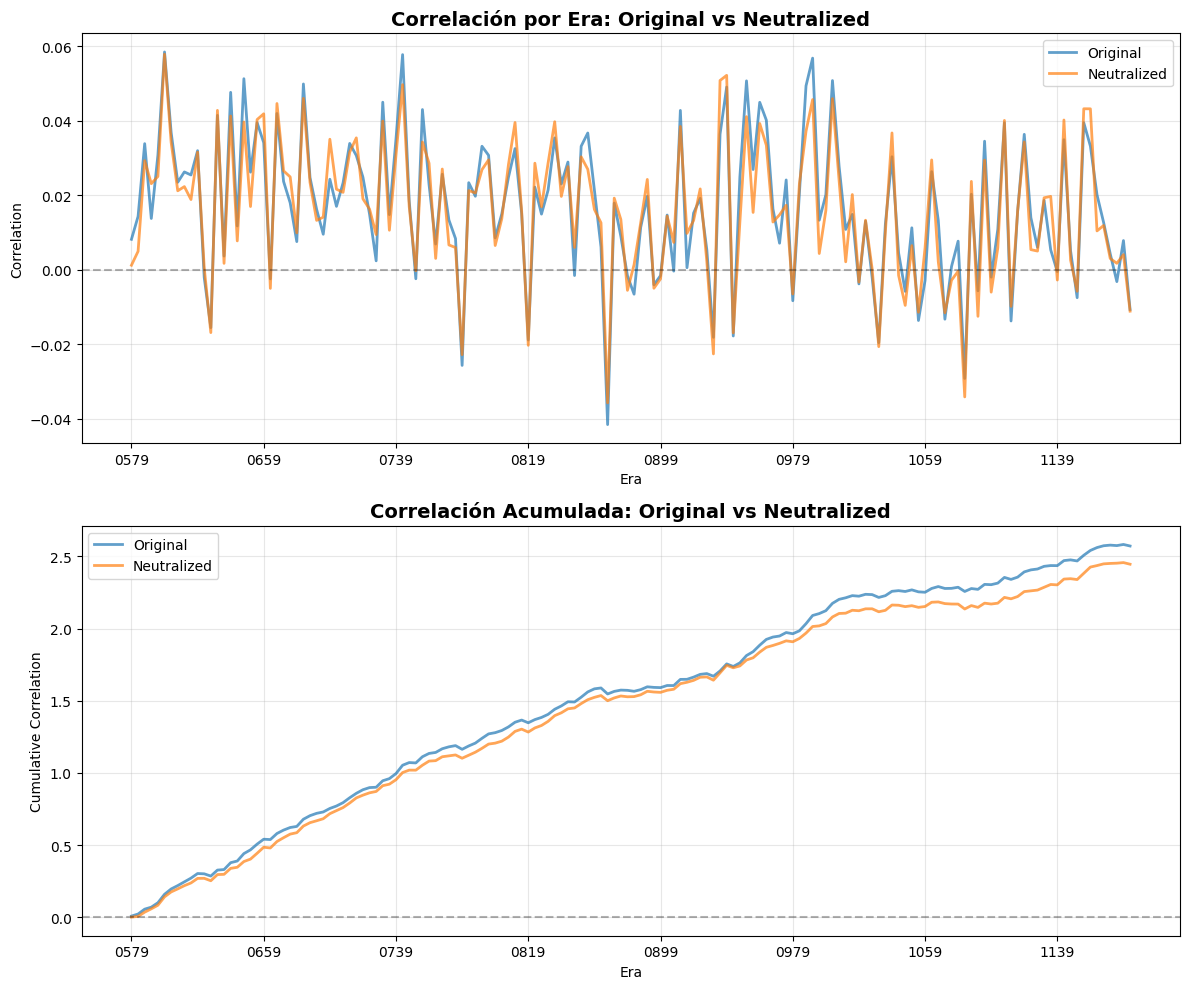


📊 INTERPRETACIÓN:
- Si la línea neutralizada es más suave → Mayor estabilidad
- Si el Sharpe mejora → Mejor ratio riesgo/retorno
- La neutralización sacrifica algo de correlación por estabilidad


In [19]:
# Visualizar la comparación de correlaciones acumuladas
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico 1: Correlación por era
ax1 = axes[0]
per_era_corr.plot(kind="line", ax=ax1, label="Original", alpha=0.7, linewidth=2)
per_era_corr_neutralized.plot(kind="line", ax=ax1, label="Neutralized", alpha=0.7, linewidth=2)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax1.set_title("Correlación por Era: Original vs Neutralized", fontsize=14, fontweight='bold')
ax1.set_xlabel("Era")
ax1.set_ylabel("Correlation")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Correlación acumulada
ax2 = axes[1]
per_era_corr.cumsum().plot(kind="line", ax=ax2, label="Original", alpha=0.7, linewidth=2)
per_era_corr_neutralized.cumsum().plot(kind="line", ax=ax2, label="Neutralized", alpha=0.7, linewidth=2)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_title("Correlación Acumulada: Original vs Neutralized", fontsize=14, fontweight='bold')
ax2.set_xlabel("Era")
ax2.set_ylabel("Cumulative Correlation")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 INTERPRETACIÓN:")
print("- Si la línea neutralizada es más suave → Mayor estabilidad")
print("- Si el Sharpe mejora → Mejor ratio riesgo/retorno")
print("- La neutralización sacrifica algo de correlación por estabilidad")


4.- SERIALIZACIÓN DEL MODELO


**¿Qué es la Serialización?**

La **serialización** es el proceso de convertir un objeto de Python (como nuestro modelo entrenado) en un formato que puede ser almacenado en disco y posteriormente recuperado.

**¿Por qué usar cloudpickle?**

- **cloudpickle** es una versión mejorada de `pickle` que puede serializar objetos más complejos
- Es especialmente útil para modelos de machine learning que contienen funciones lambda, closures o referencias a librerías externas
- Garantiza que el modelo puede ser cargado incluso en diferentes entornos

**Ventajas de la Serialización:**

1. **Reutilización**: No necesitas re-entrenar el modelo cada vez
2. **Despliegue**: Puedes mover el modelo a producción fácilmente
3. **Versionado**: Puedes guardar diferentes versiones del modelo
4. **Evaluación futura**: Facilita evaluar el modelo con nuevos datos sin depender del notebook
5. **Compartir**: Otros pueden usar tu modelo sin acceso al código de entrenamiento

**Uso Futuro:**

```python
# Para cargar el modelo más tarde:
import cloudpickle
with open('modelo_predictor.pkl', 'rb') as f:
    modelo_cargado = cloudpickle.load(f)
    
# Hacer predicciones con nuevos datos:
predicciones = modelo_cargado.predict(nuevos_datos)
```


In [20]:
import cloudpickle
import os
from datetime import datetime

# Nombre del archivo para guardar el modelo
modelo_filename = 'modelo_predictor.pkl'

print("="*70)
print("🔧 SERIALIZANDO MODELO CON CLOUDPICKLE")
print("="*70)

# Crear un diccionario con toda la información relevante del modelo
# Esto incluye no solo el modelo, sino también metadata importante
modelo_artefacto = {
    'model': model,  # El modelo LightGBM entrenado
    'feature_set': feature_set,  # Las características usadas
    'feature_metadata': feature_metadata,  # Metadata de las características
    'data_version': DATA_VERSION,  # Versión de los datos
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),  # Fecha de entrenamiento
    'model_type': 'LGBMRegressor',  # Tipo de modelo
    'model_params': model.get_params(),  # Hiperparámetros del modelo
    'validation_metrics': {  # Métricas de validación
        'mean_corr': per_era_corr.mean(),
        'std_corr': per_era_corr.std(ddof=0),
        'sharpe': per_era_corr.mean() / per_era_corr.std(ddof=0),
        'max_drawdown': (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()
    },
    'neutralize_function': neutralize_predictions  # También guardar la función de neutralización
}

# Serializar el artefacto completo
with open(modelo_filename, 'wb') as f:
    cloudpickle.dump(modelo_artefacto, f)

# Verificar que se guardó correctamente
file_size = os.path.getsize(modelo_filename) / (1024 * 1024)  # Tamaño en MB

print(f"\n✅ Modelo serializado exitosamente!")
print(f"\n📁 Archivo: {modelo_filename}")
print(f"📊 Tamaño: {file_size:.2f} MB")
print(f"📅 Fecha de entrenamiento: {modelo_artefacto['training_date']}")
print(f"🎯 Tipo de modelo: {modelo_artefacto['model_type']}")
print(f"🔢 Número de características: {len(feature_set)}")
print(f"\n📈 Métricas de validación guardadas:")
print(f"   - Mean Correlation: {modelo_artefacto['validation_metrics']['mean_corr']:.6f}")
print(f"   - Sharpe Ratio: {modelo_artefacto['validation_metrics']['sharpe']:.6f}")

print("\n" + "="*70)
print("💡 CÓMO USAR EL MODELO GUARDADO:")
print("="*70)
print("""
# 1. Cargar el modelo:
import cloudpickle
with open('modelo_predictor.pkl', 'rb') as f:
    artefacto = cloudpickle.load(f)
    
modelo = artefacto['model']
features = artefacto['feature_set']

# 2. Hacer predicciones con nuevos datos:
predicciones = modelo.predict(nuevos_datos[features])

# 3. (Opcional) Aplicar neutralización:
neutralize = artefacto['neutralize_function']
preds_neutralized = neutralize(predicciones, nuevos_datos[features], proportion=0.5)
""")


🔧 SERIALIZANDO MODELO CON CLOUDPICKLE

✅ Modelo serializado exitosamente!

📁 Archivo: modelo_predictor.pkl
📊 Tamaño: 6.48 MB
📅 Fecha de entrenamiento: 2025-10-28 18:30:43
🎯 Tipo de modelo: LGBMRegressor
🔢 Número de características: 42

📈 Métricas de validación guardadas:
   - Mean Correlation: 0.016923
   - Sharpe Ratio: 0.898501

💡 CÓMO USAR EL MODELO GUARDADO:

# 1. Cargar el modelo:
import cloudpickle
with open('modelo_predictor.pkl', 'rb') as f:
    artefacto = cloudpickle.load(f)

modelo = artefacto['model']
features = artefacto['feature_set']

# 2. Hacer predicciones con nuevos datos:
predicciones = modelo.predict(nuevos_datos[features])

# 3. (Opcional) Aplicar neutralización:
neutralize = artefacto['neutralize_function']
preds_neutralized = neutralize(predicciones, nuevos_datos[features], proportion=0.5)



In [21]:
# VALIDACIÓN: Cargar el modelo y verificar que funciona correctamente
print("="*70)
print("🧪 VERIFICANDO CARGA Y FUNCIONAMIENTO DEL MODELO SERIALIZADO")
print("="*70)

# Cargar el modelo desde el archivo
with open(modelo_filename, 'rb') as f:
    artefacto_cargado = cloudpickle.load(f)

modelo_cargado = artefacto_cargado['model']
features_cargadas = artefacto_cargado['feature_set']

# Hacer predicciones de prueba con una muestra pequeña de validation
muestra_test = validation.head(100)
predicciones_test_original = model.predict(muestra_test[feature_set])
predicciones_test_cargado = modelo_cargado.predict(muestra_test[features_cargadas])

# Verificar que las predicciones son idénticas
diferencia = np.abs(predicciones_test_original - predicciones_test_cargado).max()

print(f"\n✅ Modelo cargado exitosamente desde disco")
print(f"🔍 Diferencia máxima en predicciones: {diferencia:.10f}")

if diferencia < 1e-6:
    print("✅ ¡PERFECTO! Las predicciones son idénticas")
    print("   El modelo se serializó y cargó correctamente")
else:
    print("⚠️  Advertencia: Hay diferencias en las predicciones")
    
print("\n📋 Información del artefacto cargado:")
print(f"   - Versión de datos: {artefacto_cargado['data_version']}")
print(f"   - Fecha entrenamiento: {artefacto_cargado['training_date']}")
print(f"   - Tipo modelo: {artefacto_cargado['model_type']}")
print(f"   - Features: {len(artefacto_cargado['feature_set'])}")

print("\n" + "="*70)
print("🎉 SERIALIZACIÓN COMPLETADA Y VERIFICADA")
print("="*70)


🧪 VERIFICANDO CARGA Y FUNCIONAMIENTO DEL MODELO SERIALIZADO

✅ Modelo cargado exitosamente desde disco
🔍 Diferencia máxima en predicciones: 0.0000000000
✅ ¡PERFECTO! Las predicciones son idénticas
   El modelo se serializó y cargó correctamente

📋 Información del artefacto cargado:
   - Versión de datos: v5.0
   - Fecha entrenamiento: 2025-10-28 18:30:43
   - Tipo modelo: LGBMRegressor
   - Features: 42

🎉 SERIALIZACIÓN COMPLETADA Y VERIFICADA


5.- CONCLUSIONES Y RECOMENDACIONES


## 📊 Reflexión sobre la Práctica

### 🎯 Dificultad del Problema

Esta práctica representa uno de los **desafíos más complejos en Machine Learning aplicado a finanzas** por varias razones:

1. **Señal extremadamente ruidosa**: Las correlaciones del 2-5% son normales en mercados financieros, donde el ruido domina sobre la señal
2. **No-estacionariedad**: Los mercados cambian constantemente, lo que aprendemos hoy puede no ser válido mañana
3. **Datos ofuscados**: Trabajar sin conocer el significado real de las características requiere un enfoque puramente estadístico
4. **Horizonte temporal**: Predecir 20 días en el futuro en mercados es extremadamente difícil

### ⚠️ Feature Risk: El Riesgo Oculto

El **"feature risk"** es el riesgo de que nuestro modelo dependa demasiado de características específicas que:
- Pueden dejar de funcionar en el futuro (regime change)
- Pueden estar correlacionadas con factores de mercado no deseados
- Pueden introducir exposición a riesgos sistemáticos

**Por qué importa:**
- Un modelo con alta correlación pero alto feature risk puede tener drawdowns severos
- La neutralización de características ayuda a mitigar este riesgo
- En producción, es preferible un modelo estable (alto Sharpe) que uno volátil (alta correlación pero inconsistente)

### 🚀 Sugerencias Técnicas para Mejorar el Modelo

#### 1. **Ensemble de Modelos**
```python
# Combinar múltiples modelos diferentes
- LightGBM con diferentes hiperparámetros
- XGBoost
- Redes neuronales (MLP)
- Modelos lineales (Ridge, Lasso)
# Promediar predicciones para mayor robustez
```

#### 2. **Feature Engineering Avanzado**
- **Crear features de interacción**: Multiplicar características entre sí
- **Agregaciones temporales**: Promedios móviles de características por era
- **Rank features**: Convertir valores a rankings dentro de cada era
- **PCA**: Reducir dimensionalidad y extraer componentes principales

#### 3. **Optimización de Hiperparámetros**
```python
# Usar Optuna o GridSearchCV para optimizar:
- learning_rate: Probar valores más bajos (0.001 - 0.01)
- max_depth: Experimentar con 3-8
- num_leaves: Ajustar según max_depth
- colsample_bytree: Probar 0.1 - 0.3
- subsample: Añadir bagging (0.7 - 0.9)
```

#### 4. **Cross-Validation Temporal Avanzado**
- **Purged K-Fold**: Evitar leakage temporal
- **Embargo periods**: Respetar el overlap de targets
- **Era-based CV**: Validar en bloques de eras consecutivas

#### 5. **Neutralización Selectiva**
```python
# En lugar de neutralizar todas las features:
- Identificar features problemáticas (alta varianza)
- Neutralizar solo respecto a factores de mercado conocidos
- Usar neutralización adaptativa (varía proportion por era)
```

#### 6. **Stacking de Predicciones**
```python
# Nivel 1: Múltiples modelos base
base_models = [lgbm, xgboost, neural_net, ridge]

# Nivel 2: Meta-modelo que aprende a combinarlos
meta_model = LinearRegression()
meta_model.fit(base_predictions, target)
```

#### 7. **Target Engineering**
- Experimentar con diferentes funciones de ranking
- Probar gaussianización antes del entrenamiento
- Explorar targets alternativos (diferentes horizontes temporales)

#### 8. **Monitoreo y Re-entrenamiento**
- Implementar alertas de degradación de performance
- Re-entrenar periódicamente con datos nuevos
- Mantener rolling window de entrenamiento (últimas N eras)

### 🎓 Aprendizajes Clave

1. **La consistencia supera a la performance puntual**: Sharpe ratio > correlación absoluta
2. **El riesgo es tan importante como el retorno**: Feature risk debe monitorearse
3. **La simplicidad tiene valor**: Modelos complejos pueden overfittear en estos datos tan ruidosos
4. **La evaluación temporal es crucial**: Nunca evaluar sin respetar el orden temporal
5. **La neutralización es una herramienta poderosa**: Reduce riesgo sin necesariamente sacrificar mucha señal

### 💼 Aplicabilidad a Finanzas Cuantitativas Real

Este ejercicio replica fielmente los desafíos de:
- **Hedge funds cuantitativos**: Estrategias market-neutral
- **Asset management**: Construcción de portfolios optimizados
- **Risk management**: Control de exposiciones a factores

Las técnicas aprendidas (neutralización, validación temporal, métricas de Sharpe, drawdown) son **estándar en la industria** financiera.

---

### 🏆 Conclusión Final

Has completado una práctica de nivel profesional en Machine Learning para finanzas. Los conceptos de feature risk, neutralización, validación temporal y evaluación robusta son fundamentales para cualquier carrera en data science aplicado a mercados financieros. 

**El próximo paso**: Iterar, experimentar con las sugerencias anteriores, y nunca dejar de aprender. Los mercados siempre evolucionan, y nuestros modelos deben evolucionar con ellos.

**"In God we trust. All others must bring data."** - W. Edwards Deming
